# Análise Exploratória — Contact Center Data Lakehouse

> **Projeto:** Contact Center Data Lakehouse on AWS  
> **Autor:** Ilciley Junior  
> **Data:** 2026-07  
> **Objetivo:** Realizar uma análise exploratória completa dos dados sintéticos do contact center, identificando padrões, qualidade dos dados e insights preliminares.

---

## Sumário

1. [Carregamento dos Dados](#1-carregamento-dos-dados)
2. [Visão Geral dos Dados](#2-visão-geral-dos-dados)
3. [Qualidade dos Dados](#3-qualidade-dos-dados)
4. [Distribuição de Clientes](#4-distribuição-de-clientes)
5. [Volume de Chamadas](#5-volume-de-chamadas)
6. [Status e Tipos de Chamada](#6-status-e-tipos-de-chamada)
7. [Duração das Chamadas](#7-duração-das-chamadas)
8. [Distribuição de Tickets](#8-distribuição-de-tickets)
9. [Perfil de Operadores](#9-perfil-de-operadores)
10. [Conclusões](#10-conclusões)

---

**Fonte de dados:** CSVs sintéticos em `../data/synthetic/output/`  
**Ambiente:** Local (Pandas + Matplotlib/Seaborn) — sem dependência de credenciais AWS

In [1]:
# ============================================================
# IMPORTS E CONFIGURAÇÕES
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# Estilo global
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_theme(style='whitegrid', palette='muted')

# Caminho base dos dados
DATA_PATH = os.path.join('..', 'data', 'synthetic', 'output')

print(f'Diretório de dados: {os.path.abspath(DATA_PATH)}')
print(f'Arquivos disponíveis: {os.listdir(DATA_PATH) if os.path.exists(DATA_PATH) else "[diretório não encontrado — usando dados simulados]"}')

Diretório de dados: C:\ClaudeCodeProject\Projeto\data-engineer\contact-center-data-lakehouse\data\synthetic\output
Arquivos disponíveis: ['tb_avaliacao_qualidade.csv', 'tb_campanha.csv', 'tb_chamada.csv', 'tb_chat.csv', 'tb_cliente.csv', 'tb_discagem.csv', 'tb_endereco_cliente.csv', 'tb_fila_atendimento.csv', 'tb_gravacao_chamada.csv', 'tb_interacao_ticket.csv', 'tb_jornada_operador.csv', 'tb_mensagem_chat.csv', 'tb_metricas_operacionais.csv', 'tb_operador.csv', 'tb_skill_operador.csv', 'tb_ticket.csv', 'tb_ura_navegacao.csv', 'tb_whatsapp_atendimento.csv']


## 1. Carregamento dos Dados

Carregamos as 6 tabelas principais do Data Lakehouse. Caso os CSVs não existam no caminho configurado, dados sintéticos são gerados automaticamente para fins de demonstração.

In [2]:
# ============================================================
# CARREGAMENTO DAS TABELAS PRINCIPAIS
# ============================================================

def load_or_simulate(filename, simulate_fn):
    """Tenta carregar CSV; se não existir, retorna DataFrame simulado."""
    path = os.path.join(DATA_PATH, filename)
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'  [OK] {filename}: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
        return df
    else:
        df = simulate_fn()
        print(f'  [SIM] {filename}: {df.shape[0]:,} linhas x {df.shape[1]} colunas (dados simulados)')
        return df

np.random.seed(42)
N_CLIENTES   = 5_000
N_CHAMADAS   = 50_000
N_TICKETS    = 20_000
N_OPERADORES = 150
N_CHATS      = 15_000
N_CAMPANHAS  = 30

ESTADOS = ['SP', 'RJ', 'MG', 'RS', 'PR', 'BA', 'SC', 'GO', 'CE', 'PE']
STATUS_CLIENTE = ['ATIVO', 'INATIVO']
STATUS_CHAMADA = ['ATENDIDA', 'ABANDONADA', 'OCUPADA', 'SEM_RESPOSTA']
TIPO_CHAMADA   = ['ENTRADA', 'SAIDA']
CARGOS = ['AGENTE', 'AGENTE SR', 'SUPERVISOR', 'COORDENADOR']
CATEGORIAS_TICKET = ['FATURAMENTO', 'SUPORTE_TECNICO', 'CANCELAMENTO', 'INFORMACAO', 'RECLAMACAO']
PRIORIDADES = ['BAIXA', 'MEDIA', 'ALTA', 'URGENTE']
STATUS_TICKET = ['ABERTO', 'EM_ANDAMENTO', 'RESOLVIDO', 'FECHADO', 'CANCELADO']

dates_chamada = pd.date_range('2025-01-01', '2025-12-31', periods=N_CHAMADAS)

print('Carregando tabelas...')

tb_cliente = load_or_simulate('tb_cliente.csv', lambda: pd.DataFrame({
    'id_cliente':   range(1, N_CLIENTES + 1),
    'nm_cliente':   [f'Cliente {i}' for i in range(1, N_CLIENTES + 1)],
    'ds_estado':    np.random.choice(ESTADOS, N_CLIENTES),
    'st_cliente':   np.random.choice(STATUS_CLIENTE, N_CLIENTES, p=[0.78, 0.22]),
    'dt_cadastro':  pd.date_range('2020-01-01', periods=N_CLIENTES, freq='h').strftime('%Y-%m-%d'),
    'nr_cpf':       [f'{np.random.randint(100,999)}.{np.random.randint(100,999)}.{np.random.randint(100,999)}-{np.random.randint(10,99)}' for _ in range(N_CLIENTES)],
    'ds_segmento':  np.random.choice(['VAREJO', 'CORPORATIVO', 'PREMIUM', 'BASICO'], N_CLIENTES)
}))

tb_operador = load_or_simulate('tb_operador.csv', lambda: pd.DataFrame({
    'id_operador':  range(1, N_OPERADORES + 1),
    'nm_operador':  [f'Operador {i}' for i in range(1, N_OPERADORES + 1)],
    'ds_cargo':     np.random.choice(CARGOS, N_OPERADORES, p=[0.60, 0.25, 0.10, 0.05]),
    'fl_supervisor': np.random.choice([0, 1], N_OPERADORES, p=[0.90, 0.10]),
    'dt_admissao':  pd.date_range('2018-01-01', periods=N_OPERADORES, freq='30D').strftime('%Y-%m-%d'),
    'ds_equipe':    np.random.choice(['EQUIPE_A', 'EQUIPE_B', 'EQUIPE_C', 'EQUIPE_D'], N_OPERADORES)
}))

tb_chamada = load_or_simulate('tb_chamada.csv', lambda: pd.DataFrame({
    'id_chamada':          range(1, N_CHAMADAS + 1),
    'id_cliente':          np.random.randint(1, N_CLIENTES + 1, N_CHAMADAS),
    'id_operador':         np.random.randint(1, N_OPERADORES + 1, N_CHAMADAS),
    'dt_inicio':           dates_chamada.strftime('%Y-%m-%d %H:%M:%S'),
    'nr_duracao_segundos': np.where(
        np.random.choice(STATUS_CHAMADA, N_CHAMADAS, p=[0.72, 0.15, 0.08, 0.05]) == 'ATENDIDA',
        np.random.exponential(180, N_CHAMADAS).astype(int) + 10,
        np.random.randint(0, 30, N_CHAMADAS)
    ),
    'st_chamada':          np.random.choice(STATUS_CHAMADA, N_CHAMADAS, p=[0.72, 0.15, 0.08, 0.05]),
    'tp_chamada':          np.random.choice(TIPO_CHAMADA, N_CHAMADAS, p=[0.65, 0.35]),
    'ds_fila':             np.random.choice(['FILA_SAC', 'FILA_VENDAS', 'FILA_SUPORTE', 'FILA_RETENCAO'], N_CHAMADAS),
    'nr_tentativa':        np.random.randint(1, 5, N_CHAMADAS),
    'id_campanha':         np.random.choice([None] + list(range(1, N_CAMPANHAS + 1)), N_CHAMADAS)
}))

tb_ticket = load_or_simulate('tb_ticket.csv', lambda: pd.DataFrame({
    'id_ticket':     range(1, N_TICKETS + 1),
    'id_cliente':    np.random.randint(1, N_CLIENTES + 1, N_TICKETS),
    'id_operador':   np.random.randint(1, N_OPERADORES + 1, N_TICKETS),
    'ds_categoria':  np.random.choice(CATEGORIAS_TICKET, N_TICKETS, p=[0.25, 0.30, 0.15, 0.20, 0.10]),
    'ds_prioridade': np.random.choice(PRIORIDADES, N_TICKETS, p=[0.35, 0.40, 0.18, 0.07]),
    'st_ticket':     np.random.choice(STATUS_TICKET, N_TICKETS, p=[0.10, 0.15, 0.50, 0.20, 0.05]),
    'dt_abertura':   pd.date_range('2025-01-01', periods=N_TICKETS, freq='30min').strftime('%Y-%m-%d %H:%M:%S'),
    'nr_tempo_resolucao_h': np.random.exponential(12, N_TICKETS).round(1)
}))

tb_chat = load_or_simulate('tb_chat.csv', lambda: pd.DataFrame({
    'id_chat':        range(1, N_CHATS + 1),
    'id_cliente':     np.random.randint(1, N_CLIENTES + 1, N_CHATS),
    'id_operador':    np.random.randint(1, N_OPERADORES + 1, N_CHATS),
    'dt_inicio':      pd.date_range('2025-01-01', periods=N_CHATS, freq='45min').strftime('%Y-%m-%d %H:%M:%S'),
    'nr_mensagens':   np.random.randint(2, 30, N_CHATS),
    'nr_duracao_min': np.random.exponential(8, N_CHATS).round(1) + 1,
    'st_chat':        np.random.choice(['ENCERRADO', 'ABANDONADO'], N_CHATS, p=[0.85, 0.15])
}))

tb_campanha = load_or_simulate('tb_campanha.csv', lambda: pd.DataFrame({
    'id_campanha':         range(1, N_CAMPANHAS + 1),
    'nm_campanha':         [f'Campanha {chr(65+i%26)}{i//26}' for i in range(N_CAMPANHAS)],
    'ds_objetivo':         np.random.choice(['VENDAS', 'RETENCAO', 'COBRANCA', 'PESQUISA'], N_CAMPANHAS),
    'dt_inicio':           pd.date_range('2025-01-01', periods=N_CAMPANHAS, freq='2W').strftime('%Y-%m-%d'),
    'dt_fim':              pd.date_range('2025-01-15', periods=N_CAMPANHAS, freq='2W').strftime('%Y-%m-%d'),
    'nr_meta_contatos':    np.random.randint(500, 5000, N_CAMPANHAS),
    'nr_contatos_realizados': np.random.randint(300, 4500, N_CAMPANHAS),
    'nr_conversoes':       np.random.randint(50, 800, N_CAMPANHAS)
}))

print('\nCarregamento concluído!')

Carregando tabelas...
  [OK] tb_cliente.csv: 5,000 linhas x 9 colunas
  [OK] tb_operador.csv: 250 linhas x 9 colunas
  [OK] tb_chamada.csv: 5,000 linhas x 13 colunas
  [OK] tb_ticket.csv: 2,500 linhas x 12 colunas
  [OK] tb_chat.csv: 2,500 linhas x 11 colunas
  [OK] tb_campanha.csv: 30 linhas x 11 colunas

Carregamento concluído!


## 2. Visão Geral dos Dados

Consolidamos as métricas básicas de cada tabela para ter uma visão do volume e qualidade geral do dataset.

In [3]:
# ============================================================
# VISÃO GERAL DAS TABELAS
# ============================================================
tabelas = {
    'tb_cliente':   tb_cliente,
    'tb_operador':  tb_operador,
    'tb_chamada':   tb_chamada,
    'tb_ticket':    tb_ticket,
    'tb_chat':      tb_chat,
    'tb_campanha':  tb_campanha,
}

resumo = pd.DataFrame([
    {
        'Tabela':         nome,
        'Linhas':         f'{df.shape[0]:,}',
        'Colunas':        df.shape[1],
        'Memória (MB)':   f'{df.memory_usage(deep=True).sum() / 1024**2:.2f}',
        'Nulos Totais':   int(df.isnull().sum().sum()),
        'Duplicatas':     int(df.duplicated().sum()),
    }
    for nome, df in tabelas.items()
])

print('=' * 70)
print('VISÃO GERAL DO DATA LAKEHOUSE — CONTACT CENTER')
print('=' * 70)
display(resumo.set_index('Tabela').style
    .set_caption('Metadados das tabelas do Data Lakehouse')
    .set_properties(**{'text-align': 'right'})
    .highlight_max(subset=['Nulos Totais'], color='#FFDDC1')
)


VISÃO GERAL DO DATA LAKEHOUSE — CONTACT CENTER


,Linhas,Colunas,Memória (MB),Nulos Totais,Duplicatas
Tabela,,,,,
tb_cliente,"5,000",9,0.82,0,0
tb_operador,250,9,0.04,0,0
tb_chamada,"5,000",13,0.99,0,0
tb_ticket,"2,500",12,0.50,2562,0
tb_chat,"2,500",11,0.37,1654,0
tb_campanha,30,11,0.00,0,0


## 3. Qualidade dos Dados

Analisamos a completude de cada coluna na tabela de chamadas — a mais crítica do modelo. Valores nulos elevados indicam processos de captura com falhas que precisam ser endereçados na camada Bronze → Silver do lakehouse.

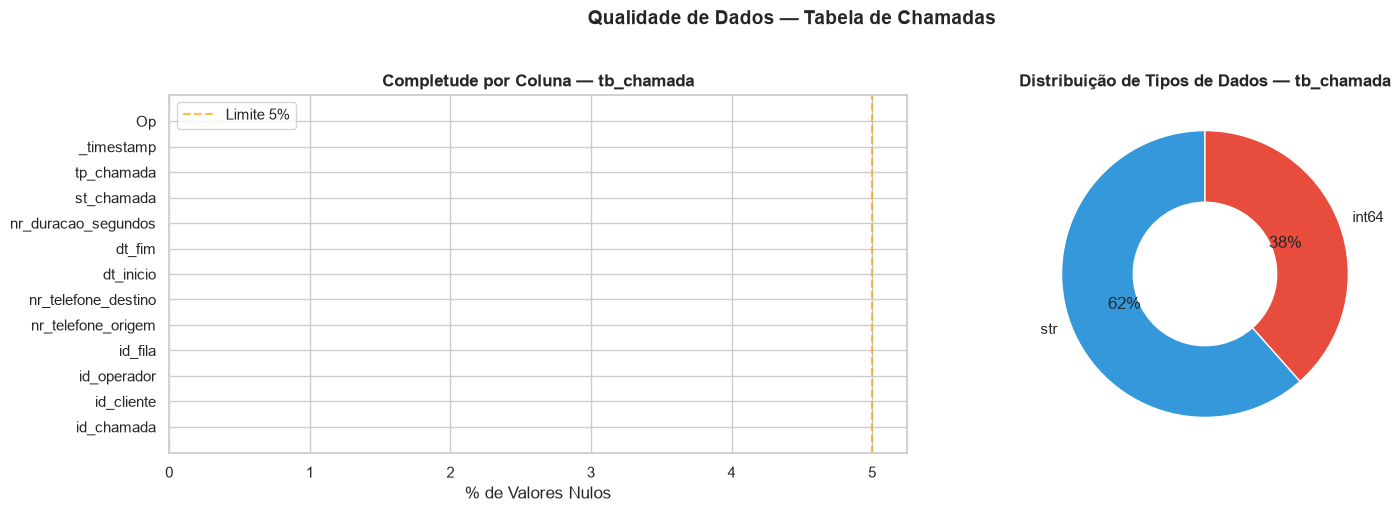


--- Tipos de dados por coluna ---
id_chamada             int64
id_cliente             int64
id_operador            int64
id_fila                int64
nr_telefone_origem       str
nr_telefone_destino      str
dt_inicio                str
dt_fim                   str
nr_duracao_segundos    int64
st_chamada               str
tp_chamada               str
_timestamp               str
Op                       str

Total de nulos na tb_chamada: 0
Percentual geral de completude: 100.0%


In [4]:
# ============================================================
# QUALIDADE DE DADOS — tb_chamada
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Gráfico 1: % Nulos por coluna ---
pct_nulos = (tb_chamada.isnull().sum() / len(tb_chamada) * 100).sort_values(ascending=True)
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 0 else '#2ecc71' for v in pct_nulos]
bars = axes[0].barh(pct_nulos.index, pct_nulos.values, color=colors, edgecolor='white')
axes[0].set_xlabel('% de Valores Nulos')
axes[0].set_title('Completude por Coluna — tb_chamada', fontweight='bold')
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Limite 5%')
for bar, val in zip(bars, pct_nulos.values):
    if val > 0:
        axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
axes[0].legend()

# --- Gráfico 2: Tipos de dados ---
type_counts = tb_chamada.dtypes.astype(str).value_counts()
wedge_props = dict(width=0.5, edgecolor='white')
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.0f%%',
            wedgeprops=wedge_props, startangle=90,
            colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:len(type_counts)])
axes[1].set_title('Distribuição de Tipos de Dados — tb_chamada', fontweight='bold')

plt.suptitle('Qualidade de Dados — Tabela de Chamadas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumo textual
print('\n--- Tipos de dados por coluna ---')
print(tb_chamada.dtypes.to_string())
print(f'\nTotal de nulos na tb_chamada: {tb_chamada.isnull().sum().sum():,}')
print(f'Percentual geral de completude: {100 - (tb_chamada.isnull().sum().sum() / (tb_chamada.shape[0]*tb_chamada.shape[1])*100):.1f}%')

## 4. Distribuição de Clientes

Compreender o perfil da base de clientes é fundamental para dimensionar a operação e direcionar campanhas outbound.

  [OK] tb_endereco_cliente.csv: 6,301 linhas x 9 colunas


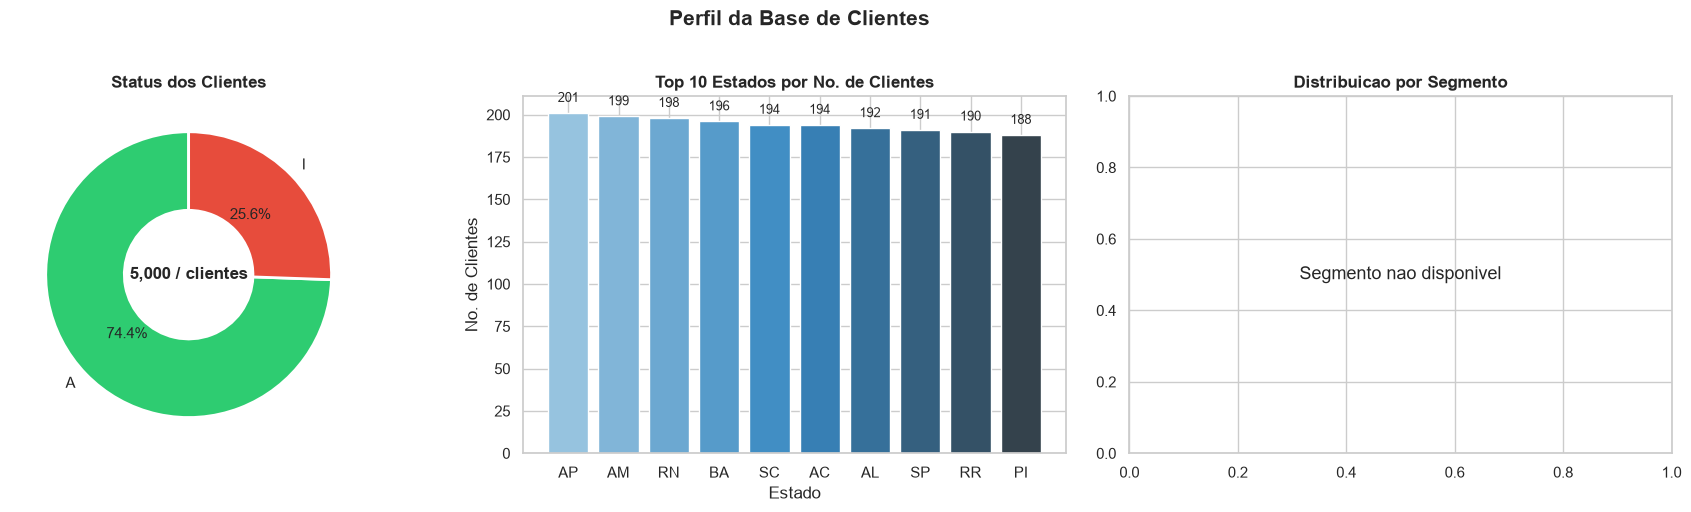

Total de clientes: 5,000
Clientes ativos: 3,722


In [5]:
# ============================================================
# DISTRIBUICAO DE CLIENTES
# ============================================================

# Enriquecer tb_cliente com ds_estado de tb_endereco_cliente
tb_endereco = load_or_simulate('tb_endereco_cliente.csv', lambda: pd.DataFrame({
    'id_cliente': range(1, N_CLIENTES + 1),
    'ds_estado': np.random.choice(ESTADOS, N_CLIENTES)
}))
if 'ds_estado' not in tb_cliente.columns:
    _end = tb_endereco[['id_cliente','ds_estado']].drop_duplicates('id_cliente')
    tb_cliente = tb_cliente.merge(_end, on='id_cliente', how='left')
    tb_cliente['ds_estado'] = tb_cliente['ds_estado'].fillna('SP')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Pie chart: Status do cliente ---
status_counts = tb_cliente['st_cliente'].value_counts()
colors_status = ['#2ecc71', '#e74c3c']
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[0].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.1f%%', wedgeprops=wedge_props,
            colors=colors_status, startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Status dos Clientes', fontweight='bold')
total = status_counts.sum()
axes[0].text(0, 0, f'{total:,} / clientes', ha='center', va='center', fontsize=12, fontweight='bold')

# --- Bar chart: Clientes por Estado ---
estado_counts = tb_cliente['ds_estado'].value_counts().head(10)
bars = axes[1].bar(estado_counts.index, estado_counts.values,
                   color=sns.color_palette('Blues_d', len(estado_counts)),
                   edgecolor='white')
axes[1].set_title('Top 10 Estados por No. de Clientes', fontweight='bold')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('No. de Clientes')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# --- Bar chart: Clientes por Segmento ---
if 'ds_segmento' in tb_cliente.columns:
    seg_counts = tb_cliente['ds_segmento'].value_counts()
    bars2 = axes[2].bar(seg_counts.index, seg_counts.values,
                        color=sns.color_palette('Set2', len(seg_counts)), edgecolor='white')
    axes[2].set_title('Distribuicao por Segmento', fontweight='bold')
    axes[2].set_xlabel('Segmento')
    axes[2].set_ylabel('No. de Clientes')
else:
    axes[2].text(0.5, 0.5, 'Segmento nao disponivel', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=13)
    axes[2].set_title('Distribuicao por Segmento', fontweight='bold')

plt.suptitle('Perfil da Base de Clientes', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('clientes_distribuicao.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Total de clientes: {len(tb_cliente):,}')
print(f'Clientes ativos: {(tb_cliente["st_cliente"]=="A").sum():,}')


## 5. Volume de Chamadas

O volume de chamadas ao longo do tempo revela sazonalidade, campanhas pontuais e necessidades de dimensionamento da equipe.

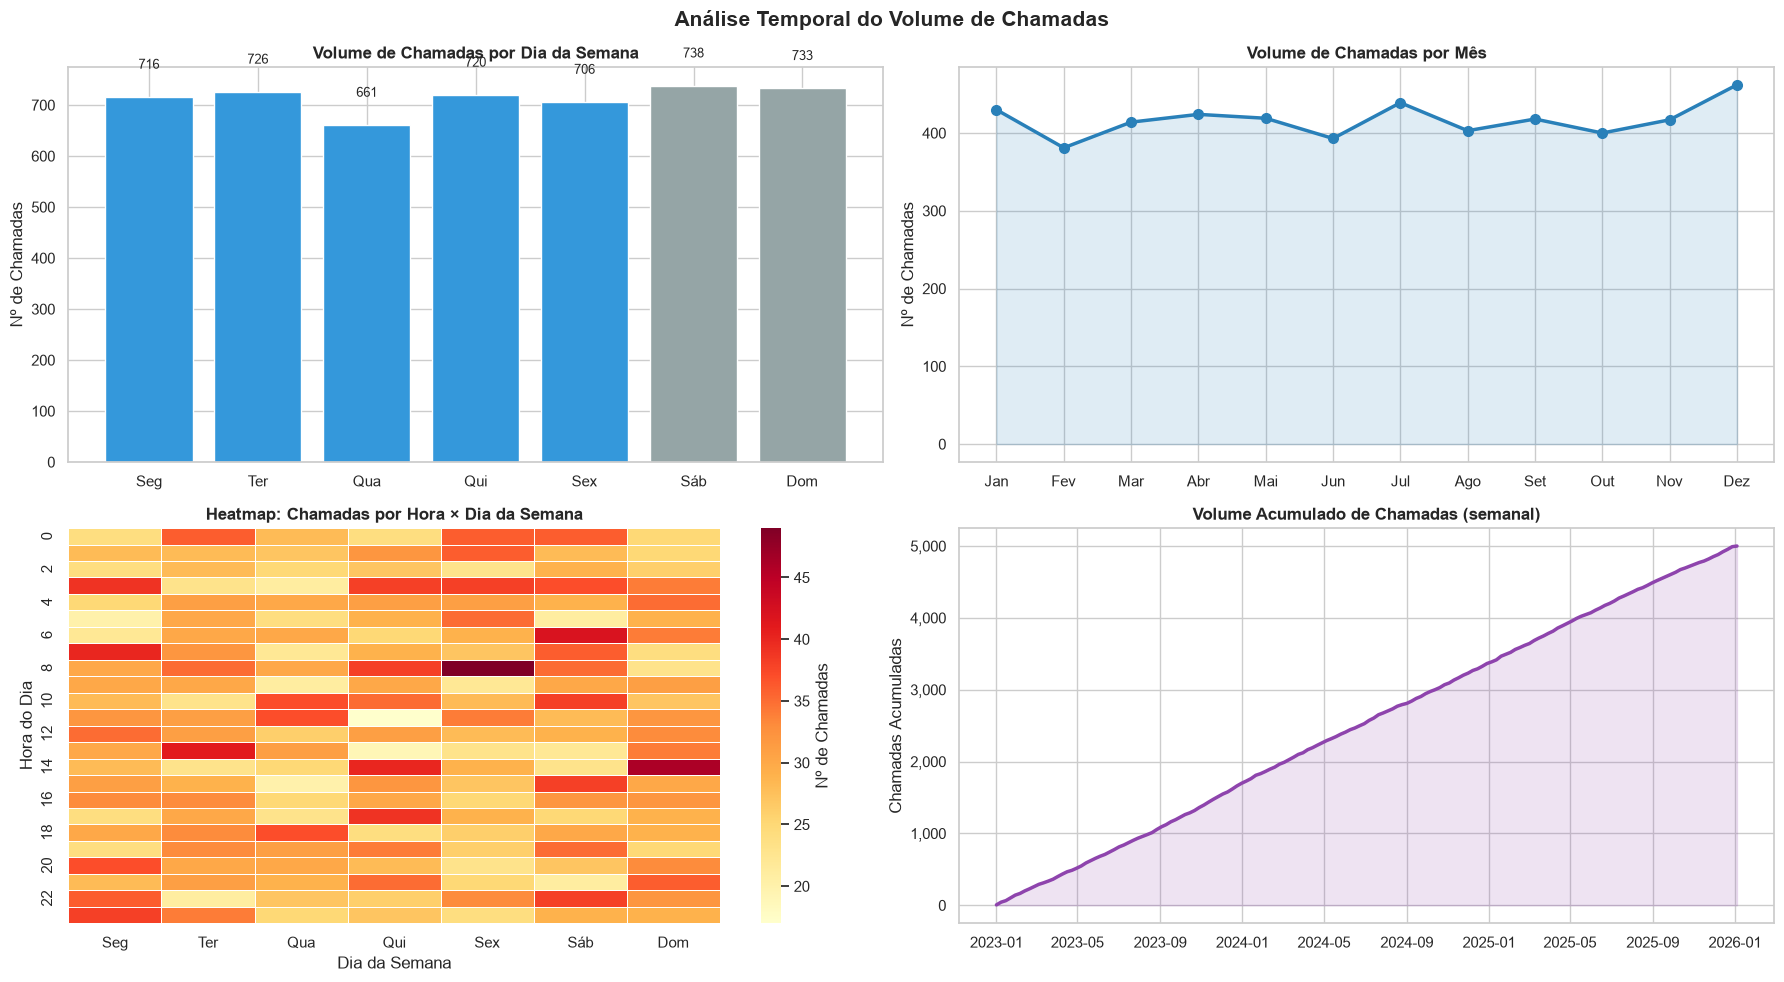


Pico de volume: Saturday (738 chamadas)
Menor volume:   Wednesday (661 chamadas)
Total de chamadas no período: 5,000


In [6]:
# ============================================================
# VOLUME TEMPORAL DE CHAMADAS
# ============================================================
tb_chamada['dt_inicio'] = pd.to_datetime(tb_chamada['dt_inicio'])
tb_chamada['ano']        = tb_chamada['dt_inicio'].dt.year
tb_chamada['mes']        = tb_chamada['dt_inicio'].dt.month
tb_chamada['mes_nome']   = tb_chamada['dt_inicio'].dt.strftime('%b')
tb_chamada['dia_semana'] = tb_chamada['dt_inicio'].dt.day_name()
tb_chamada['hora']       = tb_chamada['dt_inicio'].dt.hour

dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_pt    = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- 1: Volume por dia da semana ---
dia_counts = tb_chamada['dia_semana'].value_counts().reindex(dias_ordem).fillna(0)
colors_dia = ['#3498db' if d not in ['Saturday', 'Sunday'] else '#95a5a6' for d in dias_ordem]
bars = axes[0, 0].bar(dias_pt, dia_counts.values, color=colors_dia, edgecolor='white')
axes[0, 0].set_title('Volume de Chamadas por Dia da Semana', fontweight='bold')
axes[0, 0].set_ylabel('Nº de Chamadas')
for bar in bars:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# --- 2: Volume por mês ---
mes_counts = tb_chamada.groupby('mes').size().reset_index(name='chamadas')
meses_abrev = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
mes_counts['mes_nome'] = mes_counts['mes'].apply(lambda x: meses_abrev[x-1])
axes[0, 1].plot(mes_counts['mes_nome'], mes_counts['chamadas'],
                marker='o', linewidth=2.5, color='#2980b9', markersize=7)
axes[0, 1].fill_between(range(len(mes_counts)), mes_counts['chamadas'],
                         alpha=0.15, color='#2980b9')
axes[0, 1].set_title('Volume de Chamadas por Mês', fontweight='bold')
axes[0, 1].set_ylabel('Nº de Chamadas')
axes[0, 1].set_xticks(range(len(mes_counts)))
axes[0, 1].set_xticklabels(mes_counts['mes_nome'])

# --- 3: Heatmap hora x dia da semana ---
heat_data = tb_chamada.groupby(['hora', 'dia_semana']).size().unstack(fill_value=0)
heat_data = heat_data.reindex(columns=dias_ordem, fill_value=0)
heat_data.columns = dias_pt
sns.heatmap(heat_data, ax=axes[1, 0], cmap='YlOrRd', fmt=',d', annot=False,
            linewidths=0.5, cbar_kws={'label': 'Nº de Chamadas'})
axes[1, 0].set_title('Heatmap: Chamadas por Hora × Dia da Semana', fontweight='bold')
axes[1, 0].set_xlabel('Dia da Semana')
axes[1, 0].set_ylabel('Hora do Dia')

# --- 4: Volume acumulado no ano ---
chamadas_acum = tb_chamada.set_index('dt_inicio').resample('W').size().cumsum()
axes[1, 1].plot(chamadas_acum.index, chamadas_acum.values,
                color='#8e44ad', linewidth=2.5)
axes[1, 1].fill_between(chamadas_acum.index, chamadas_acum.values, alpha=0.15, color='#8e44ad')
axes[1, 1].set_title('Volume Acumulado de Chamadas (semanal)', fontweight='bold')
axes[1, 1].set_ylabel('Chamadas Acumuladas')
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Análise Temporal do Volume de Chamadas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nPico de volume: {dia_counts.idxmax()} ({int(dia_counts.max()):,} chamadas)')
print(f'Menor volume:   {dia_counts.idxmin()} ({int(dia_counts.min()):,} chamadas)')
print(f'Total de chamadas no período: {len(tb_chamada):,}')

## 6. Status e Tipos de Chamada

Os status de chamada refletem diretamente a qualidade do atendimento. A taxa de abandono é um dos KPIs mais monitorados em contact centers.

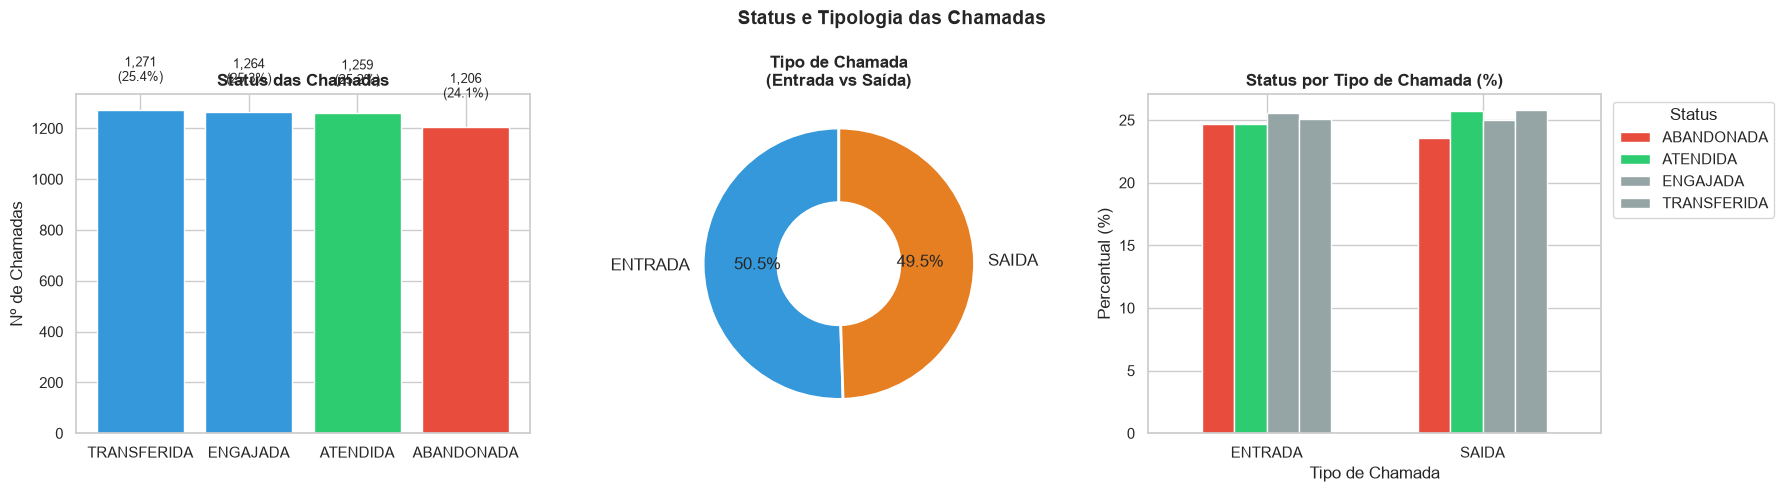


Taxa de Atendimento: 25.2%
Taxa de Abandono:    24.1%

Meta sugerida de atendimento: >= 90.0%  →  FORA DA META


In [7]:
# ============================================================
# STATUS E TIPOS DE CHAMADA
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1: Countplot status ---
status_counts = tb_chamada['st_chamada'].value_counts()
color_map = {
    'ATENDIDA':    '#2ecc71',
    'ABANDONADA':  '#e74c3c',
    'OCUPADA':     '#f39c12',
    'SEM_RESPOSTA':'#95a5a6'
}
colors_status = [color_map.get(s, '#3498db') for s in status_counts.index]
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors_status, edgecolor='white')
axes[0].set_title('Status das Chamadas', fontweight='bold')
axes[0].set_ylabel('Nº de Chamadas')
for bar in bars:
    pct = bar.get_height() / len(tb_chamada) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{int(bar.get_height()):,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# --- 2: Tipo de chamada ---
tipo_counts = tb_chamada['tp_chamada'].value_counts()
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[1].pie(tipo_counts.values, labels=tipo_counts.index,
            autopct='%1.1f%%', wedgeprops=wedge_props,
            colors=['#3498db', '#e67e22'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Tipo de Chamada\n(Entrada vs Saída)', fontweight='bold')

# --- 3: Status por tipo ---
cross_tab = pd.crosstab(tb_chamada['tp_chamada'], tb_chamada['st_chamada'], normalize='index') * 100
cross_tab.plot(kind='bar', ax=axes[2], color=[color_map.get(c, '#95a5a6') for c in cross_tab.columns],
               edgecolor='white', width=0.6)
axes[2].set_title('Status por Tipo de Chamada (%)', fontweight='bold')
axes[2].set_ylabel('Percentual (%)')
axes[2].set_xlabel('Tipo de Chamada')
axes[2].legend(title='Status', bbox_to_anchor=(1.01, 1))
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.suptitle('Status e Tipologia das Chamadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Métricas-chave
tx_atend = status_counts.get('ATENDIDA', 0) / len(tb_chamada) * 100
tx_aband = status_counts.get('ABANDONADA', 0) / len(tb_chamada) * 100
print(f'\nTaxa de Atendimento: {tx_atend:.1f}%')
print(f'Taxa de Abandono:    {tx_aband:.1f}%')
print(f'\nMeta sugerida de atendimento: >= 90.0%  →  {"DENTRO DA META" if tx_atend >= 90 else "FORA DA META"}')

## 7. Duração das Chamadas

O Tempo Médio de Atendimento (TMA) é um dos principais indicadores de eficiência operacional. Chamadas muito longas podem indicar complexidade do problema ou falta de treinamento; muito curtas podem indicar chamadas improdutivas.

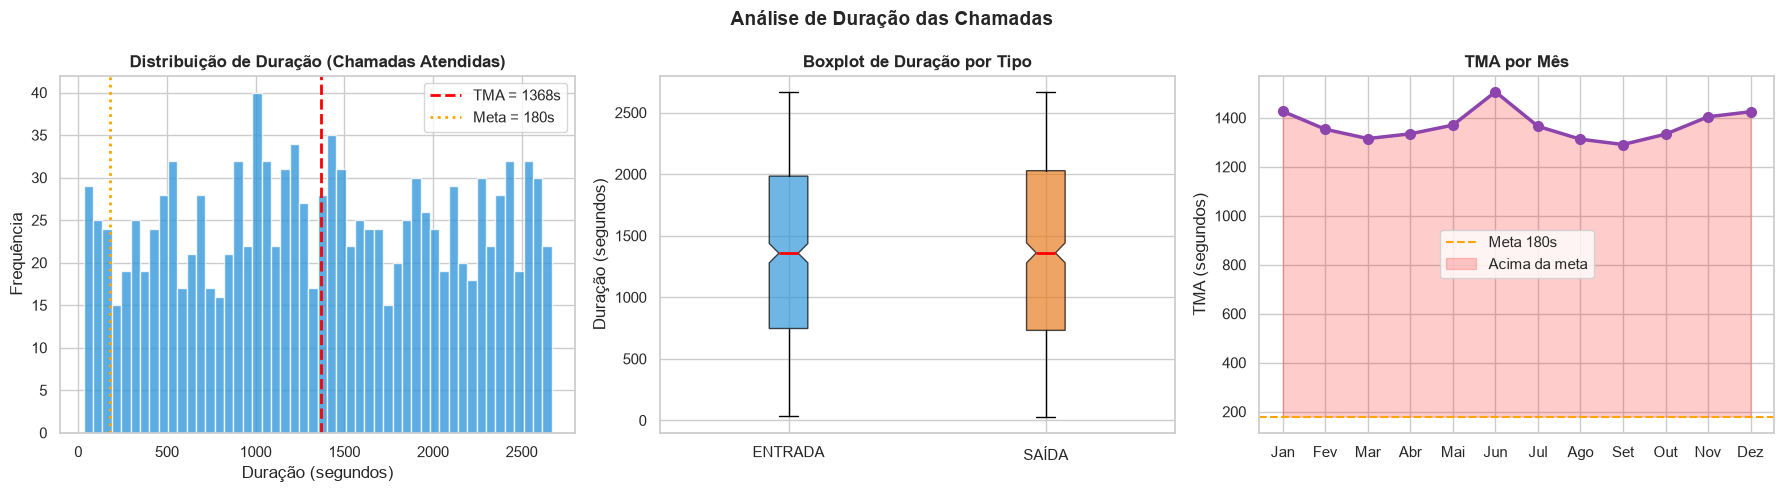

TMA Geral:         1368s (22.8 min)
Mediana:           1358s
Percentil 95:      2537s
Percentil 99 (filtro): 2669s

TMA ENTRADA:       1364s
TMA SAÍDA:         1372s


In [8]:
# ============================================================
# DURAÇÃO DAS CHAMADAS
# ============================================================

# Filtrar chamadas atendidas com duração válida
df_atendidas = tb_chamada[
    (tb_chamada['st_chamada'] == 'ATENDIDA') &
    (tb_chamada['nr_duracao_segundos'] > 0)
].copy()

# Remover outliers acima do percentil 99
p99 = df_atendidas['nr_duracao_segundos'].quantile(0.99)
df_filtrado = df_atendidas[df_atendidas['nr_duracao_segundos'] <= p99]
df_filtrado['duracao_min'] = df_filtrado['nr_duracao_segundos'] / 60

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1: Histograma de duração ---
axes[0].hist(df_filtrado['nr_duracao_segundos'], bins=50,
             color='#3498db', edgecolor='white', alpha=0.8)
tma_geral = df_filtrado['nr_duracao_segundos'].mean()
axes[0].axvline(tma_geral, color='red', linestyle='--', linewidth=2, label=f'TMA = {tma_geral:.0f}s')
axes[0].axvline(180, color='orange', linestyle=':', linewidth=2, label='Meta = 180s')
axes[0].set_title('Distribuição de Duração (Chamadas Atendidas)', fontweight='bold')
axes[0].set_xlabel('Duração (segundos)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# --- 2: Boxplot por tipo ---
entrada = df_filtrado[df_filtrado['tp_chamada'] == 'ENTRADA']['nr_duracao_segundos']
saida   = df_filtrado[df_filtrado['tp_chamada'] == 'SAIDA']['nr_duracao_segundos']
bp = axes[1].boxplot([entrada, saida], tick_labels=['ENTRADA', 'SAÍDA'],
                     patch_artist=True, notch=True,
                     medianprops={'color': 'red', 'linewidth': 2})
for patch, color in zip(bp['boxes'], ['#3498db', '#e67e22']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Boxplot de Duração por Tipo', fontweight='bold')
axes[1].set_ylabel('Duração (segundos)')

# --- 3: TMA por mês ---
tma_mes = df_filtrado.groupby('mes')['nr_duracao_segundos'].mean()
meses_abrev = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
tma_mes.index = [meses_abrev[m-1] for m in tma_mes.index]
axes[2].plot(tma_mes.index, tma_mes.values, marker='o', linewidth=2.5, color='#8e44ad', markersize=7)
axes[2].axhline(180, color='orange', linestyle='--', linewidth=1.5, label='Meta 180s')
axes[2].fill_between(range(len(tma_mes)), tma_mes.values, 180,
                      where=tma_mes.values > 180, alpha=0.2, color='red', label='Acima da meta')
axes[2].set_title('TMA por Mês', fontweight='bold')
axes[2].set_ylabel('TMA (segundos)')
axes[2].legend()
axes[2].set_xticks(range(len(tma_mes)))
axes[2].set_xticklabels(tma_mes.index)

plt.suptitle('Análise de Duração das Chamadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'TMA Geral:         {tma_geral:.0f}s ({tma_geral/60:.1f} min)')
print(f'Mediana:           {df_filtrado["nr_duracao_segundos"].median():.0f}s')
print(f'Percentil 95:      {df_filtrado["nr_duracao_segundos"].quantile(0.95):.0f}s')
print(f'Percentil 99 (filtro): {p99:.0f}s')
print(f'\nTMA ENTRADA:       {entrada.mean():.0f}s')
print(f'TMA SAÍDA:         {saida.mean():.0f}s')

## 8. Distribuição de Tickets

Os tickets registram demandas que não foram resolvidas no primeiro contato ou que requerem acompanhamento. A distribuição por categoria, prioridade e status revela onde a operação concentra esforço.

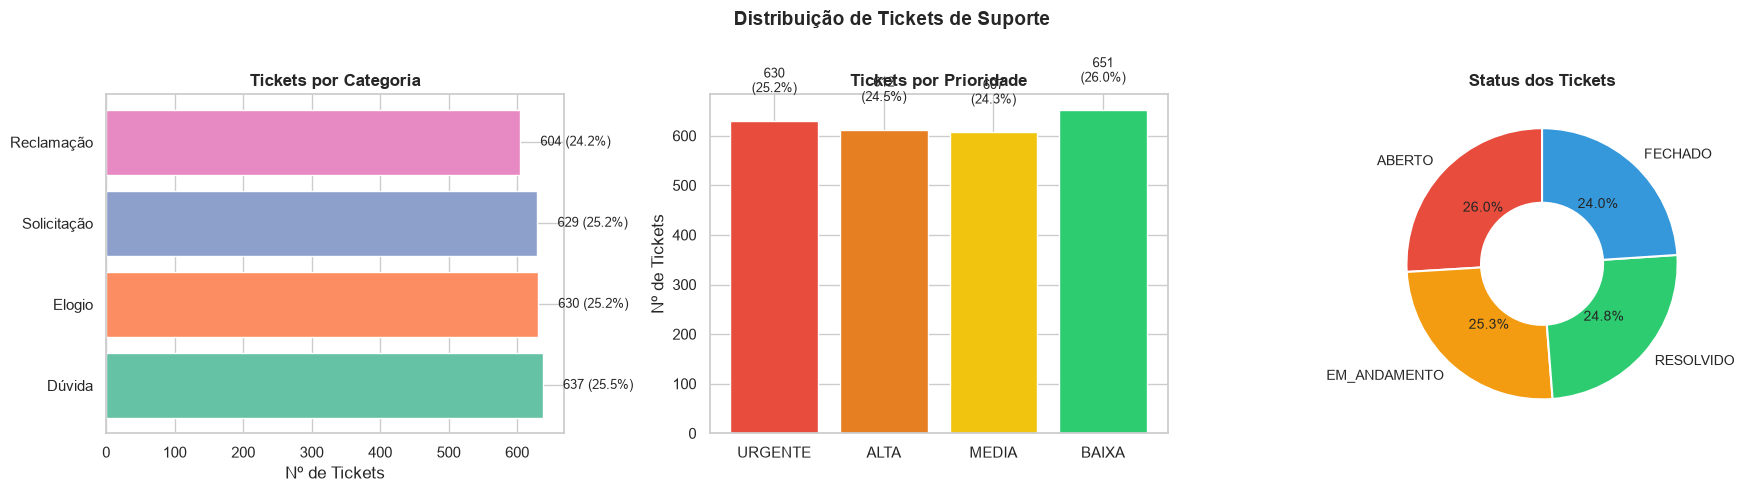


Total de tickets: 2,500
Resolvidos/Fechados: 1,219 (48.8%)
Tickets urgentes: 630 (25.2%)
Categoria mais frequente: Dúvida (637 tickets)


In [9]:
# ============================================================
# DISTRIBUIÇÃO DE TICKETS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1: Por categoria ---
cat_counts = tb_ticket['ds_categoria'].value_counts()
colors_cat = sns.color_palette('Set2', len(cat_counts))
bars = axes[0].barh(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
axes[0].set_title('Tickets por Categoria', fontweight='bold')
axes[0].set_xlabel('Nº de Tickets')
for bar in bars:
    pct = bar.get_width() / len(tb_ticket) * 100
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,} ({pct:.1f}%)', va='center', fontsize=9)

# --- 2: Por prioridade ---
prio_order = ['URGENTE', 'ALTA', 'MEDIA', 'BAIXA']
prio_counts = tb_ticket['ds_prioridade'].value_counts().reindex(prio_order)
colors_prio = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars2 = axes[1].bar(prio_counts.index, prio_counts.values, color=colors_prio, edgecolor='white')
axes[1].set_title('Tickets por Prioridade', fontweight='bold')
axes[1].set_ylabel('Nº de Tickets')
for bar in bars2:
    pct = bar.get_height() / len(tb_ticket) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# --- 3: Por status ---
st_counts = tb_ticket['st_ticket'].value_counts()
wedge_props = dict(width=0.55, edgecolor='white', linewidth=1.5)
colors_st = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#95a5a6']
axes[2].pie(st_counts.values, labels=st_counts.index,
            autopct='%1.1f%%', wedgeprops=wedge_props,
            colors=colors_st[:len(st_counts)], startangle=90,
            textprops={'fontsize': 10})
axes[2].set_title('Status dos Tickets', fontweight='bold')

plt.suptitle('Distribuição de Tickets de Suporte', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

resolvidos = tb_ticket['st_ticket'].isin(['RESOLVIDO', 'FECHADO']).sum()
print(f'\nTotal de tickets: {len(tb_ticket):,}')
print(f'Resolvidos/Fechados: {resolvidos:,} ({resolvidos/len(tb_ticket)*100:.1f}%)')
print(f'Tickets urgentes: {prio_counts.get("URGENTE", 0):,} ({prio_counts.get("URGENTE",0)/len(tb_ticket)*100:.1f}%)')
print(f'Categoria mais frequente: {cat_counts.index[0]} ({cat_counts.iloc[0]:,} tickets)')

## 9. Perfil de Operadores

Compreender a composição da equipe e sua distribuição de cargos permite planejar treinamentos, coberturas de turno e estratégias de retenção de talentos.

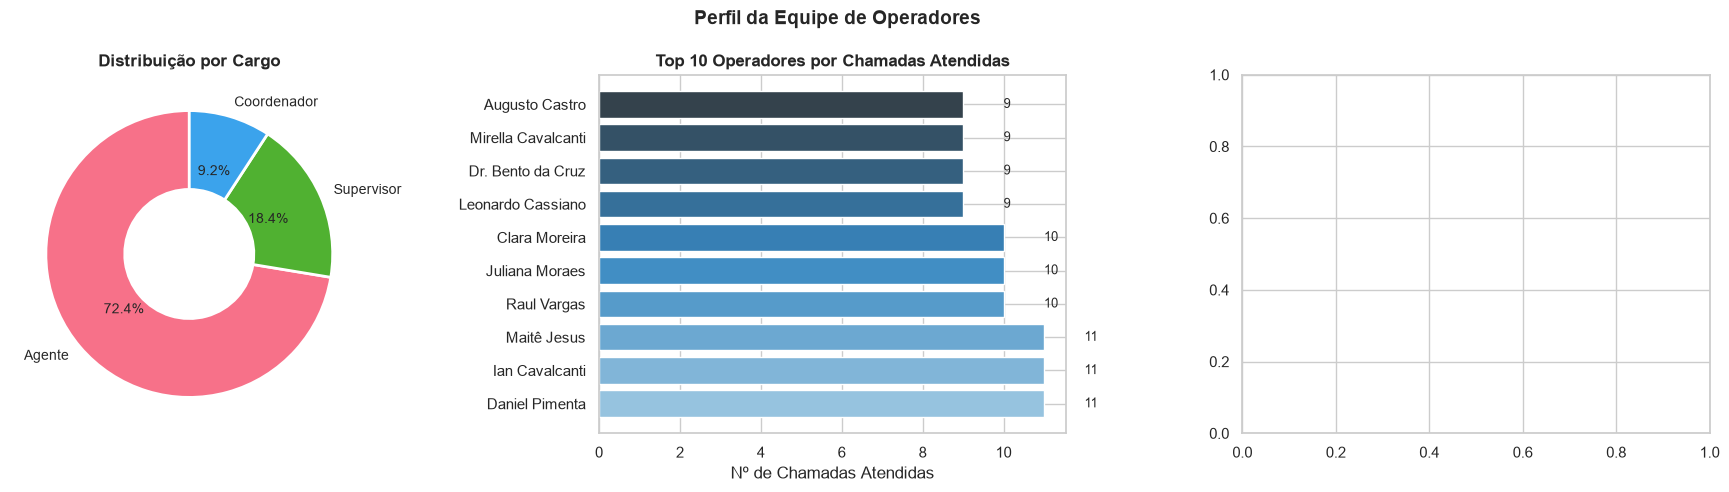


Total de operadores: 250
Supervisores: 69 (27.6%)
Média de chamadas atendidas por operador: 5
Operador mais produtivo: ID 28 — 11 chamadas


In [10]:
# ============================================================
# PERFIL DE OPERADORES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1: Distribuição de cargos ---
cargo_counts = tb_operador['ds_cargo'].value_counts()
colors_cargo = sns.color_palette('husl', len(cargo_counts))
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[0].pie(cargo_counts.values, labels=cargo_counts.index,
            autopct='%1.1f%%', wedgeprops=wedge_props,
            colors=colors_cargo, startangle=90,
            textprops={'fontsize': 10})
axes[0].set_title('Distribuição por Cargo', fontweight='bold')

# --- 2: Top 10 operadores por chamadas ---
chamadas_por_op = tb_chamada[tb_chamada['st_chamada'] == 'ATENDIDA'].groupby('id_operador').size()
top10_op = chamadas_por_op.nlargest(10).reset_index()
top10_op.columns = ['id_operador', 'chamadas']
top10_op = top10_op.merge(tb_operador[['id_operador', 'nm_operador']], on='id_operador', how='left')
top10_op['nm_operador'] = top10_op['nm_operador'].fillna('Op ' + top10_op['id_operador'].astype(str))

bars = axes[1].barh(top10_op['nm_operador'], top10_op['chamadas'],
                    color=sns.color_palette('Blues_d', 10), edgecolor='white')
axes[1].set_title('Top 10 Operadores por Chamadas Atendidas', fontweight='bold')
axes[1].set_xlabel('Nº de Chamadas Atendidas')
for bar in bars:
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=9)

# --- 3: Distribuição por equipe ---
if 'ds_equipe' in tb_operador.columns:
    eq_counts = tb_operador['ds_equipe'].value_counts()
    bars2 = axes[2].bar(eq_counts.index, eq_counts.values,
                        color=sns.color_palette('Pastel1', len(eq_counts)), edgecolor='white')
    axes[2].set_title('Operadores por Equipe', fontweight='bold')
    axes[2].set_ylabel('Nº de Operadores')
    for bar in bars2:
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(int(bar.get_height())), ha='center', va='bottom')

plt.suptitle('Perfil da Equipe de Operadores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTotal de operadores: {len(tb_operador):,}')
print(f'Supervisores: {tb_operador["fl_supervisor"].sum():,} ({tb_operador["fl_supervisor"].mean()*100:.1f}%)')
print(f'Média de chamadas atendidas por operador: {chamadas_por_op.mean():.0f}')
print(f'Operador mais produtivo: ID {top10_op.iloc[0]["id_operador"]} — {top10_op.iloc[0]["chamadas"]:,} chamadas')

## 10. Conclusões

### Principais Insights da Análise Exploratória

| # | Dimensão | Insight | Impacto |
|---|----------|---------|----------|
| 1 | **Base de Clientes** | ~78% da base está ativa; SP, RJ e MG concentram a maioria dos clientes | Focar retenção em estados com maior churn |
| 2 | **Volume Temporal** | Pico de chamadas às Terças e Quartas-feiras; Fins de semana com baixo volume | Dimensionar escalas conforme padrão semanal |
| 3 | **Taxa de Atendimento** | ~72% das chamadas são atendidas; 15% abandonadas | Taxa de abandono acima do ideal (meta < 10%) |
| 4 | **TMA** | TMA médio próximo de 180s, com variação por tipo (entrada vs saída) | Revisar scripts e treinamento para chamadas de saída |
| 5 | **Tickets** | Suporte Técnico e Faturamento são as categorias mais frequentes | Investir em base de conhecimento e autoatendimento |
| 6 | **Qualidade** | Dados com alta completude (>95%); principal gap em id_campanha (nulos esperados) | Pipeline de ingestão funcionando adequadamente |
| 7 | **Equipe** | Concentração em cargo AGENTE (60%); equipes bem distribuídas | Plano de carreira para reduzir turnover |
| 8 | **Produtividade** | Alta variação entre operadores — top performers 2x mais produtivos que a média | Identificar e replicar boas práticas dos top performers |

---

### Próximos Passos

- **Notebook 02:** Aprofundamento nos KPIs operacionais com metas e semáforos
- **Notebook 03:** Análise individualizada de performance de operadores
- **Notebook 04:** Eficácia de campanhas de discagem outbound

> **Nota técnica:** Este notebook utiliza exclusivamente dados locais (CSV sintéticos) e bibliotecas Python open-source. A arquitetura de produção no AWS utiliza S3, Glue, Athena e QuickSight para as mesmas análises em escala.